# Bayesian Inference for Mass-Action Kinetics Model

Based on inference_pymc.py by Nathaniel Linden (UCSD MAE) - 2024

Edited by Annette Thompson (CU Boulder) - 2026

## Import Libraries

In [10]:
import os, jax, json, nutpie
import jax.numpy as jnp
import numpy as np
import pandas as pd
import diffrax as dfrx
import equinox as eqx
import pymc as pm
import arviz as az

from pytensor.link.jax.dispatch import jax_funcify


from utils import *
from reaction_model_builder import build_ode_system_from_reactions

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

print(f"JAX version: {jax.__version__}")
print(f"PyMC version: {pm.__version__}")
print(f"Number of JAX devices: {jax.device_count()}")

JAX version: 0.7.0
PyMC version: 5.27.1
Number of JAX devices: 4


## Designate File Locations

Eventually, this will be done in the command line using a .yaml file or something like that.

Still need to integrate in how/where I want data to be imported.

In [11]:
reactions_file = "./reactions_MA.json"
solver_params_file = "./solver_params.json"
data_file = "./Data/Duggleby_Clarke_1991_Fig2.csv"

savedir = "./MA_Results"
prior_samples_file = "MA_prior_samples_pm.nc"
posterior_samples_file = "MA_mcmc_samples_pm.nc"

print(f"Reaction file: {reactions_file}")
print(f"Solver parameters file: {solver_params_file}")
print(f"Save directory: {savedir}")

Reaction file: ./reactions_MA.json
Solver parameters file: ./solver_params.json
Save directory: ./MA_Results


## Create Save Directory

In [12]:
# Create save directory if it doesn't exist
if not os.path.isdir(savedir):
    os.makedirs(savedir)
    print(f"Created directory: {savedir}")
else:
    print(f"Save directory exists: {savedir}")

Save directory exists: ./MA_Results


## Load Model Reactions and Build ODEs

In [13]:
# Load solver parameters and reactions
with open(solver_params_file, 'r') as file:
    solver_params = json.load(file)

# Build ODE system from reactions
ode_system, species_names, param_names, param_values = build_ode_system_from_reactions(reactions_file)

# Extract free parameters from the new format
free_params = [p['param_name'] for p in solver_params['free_kinetic_params']]

print(f"Species names: {species_names}")
print(f"Parameter names: {param_names}")
print(f"Free parameters: {free_params}")
print(f"Parameter nominal values: {param_values}")

Species names: ['S', 'E', 'ES', 'P']
Parameter names: ['k_f', 'k_r', 'k_cat']
Free parameters: ['k_f', 'k_r', 'k_cat']
Parameter nominal values: {'k_f': 0.1, 'k_r': 0.025, 'k_cat': 1.0}


## Load Data

Again, need to figure out how/where data will be loaded and how/where calculations on the ODE solution will be designated for comparison.

In [14]:
# Load the data
loaded_data = pd.read_csv(data_file)
times = loaded_data['time'].to_numpy()
data = loaded_data['[P]/[S_tot]'].to_numpy()

# Assume data std is 5% of the mean
data_std = 0.05 * np.mean(data)

print(f"Data loaded from: {data_file}")
print(f"Number of time points: {len(times)}")
print(f"Time range: {times[0]:.1f} to {times[-1]:.1f} minutes")
print(f"Data mean: {np.mean(data):.2f}, std: {data_std:.2f}")

# Display data points
display(loaded_data)

Data loaded from: ./Data/Duggleby_Clarke_1991_Fig2.csv
Number of time points: 11
Time range: 0.0 to 23.3 minutes
Data mean: 0.34, std: 0.02


,time,[P]/[S_tot]
0,0.0,0.00
1,2.3,0.08
2,4.7,0.16
3,7.0,0.23
4,9.4,0.29
5,11.7,0.36
6,14.0,0.42
7,16.4,0.48
8,18.7,0.52
9,21.0,0.58


## Define Simulator Function

In [15]:
# ODE solver setup

# Extract ODE solver parameters - automatically set variables from config
ode_solver_config = solver_params.get('ODE_solver', {})
for key, value in ode_solver_config.items():
    if value is not None:
        globals()[key] = value

ode_controller_config = solver_params.get('ODE_stepsize_controller', {})

# There is probably a better way to pull in parameters (look into this)
for key, value in ode_controller_config.items():
    if value is not None:
        globals()[key] = value

solver = eval('dfrx.' + solver_name + '()')
stepsize_controller = dfrx.PIDController(**{k: v for k, v in ode_controller_config.items()})
t0 = 0.0
t1 = times[-1]
saveat = dfrx.SaveAt(ts=times)

# Build y0 with all species, defaulting to 0 if not specified in solver_params
provided_init_conds = solver_params.get("init_conds", {})
y0 = []
for species in species_names:
    y0.append(provided_init_conds.get(species, 0.0))
y0_jax = jnp.array(y0)

# Create the ODE term with the dynamically built system
rhs = dfrx.ODETerm(ode_system)

def simulator(params):
    """Solve ODE and compute product/(substrate + product) ratio"""
    # Solve model
    sol = dfrx.diffeqsolve(
        rhs, solver, t0=t0, t1=t1, dt0=dt0, 
        y0=y0_jax, args=params, saveat=saveat,
        stepsize_controller=stepsize_controller,
        max_steps=max_steps, throw=True 
    )
    sol = jnp.squeeze(sol.ys)

    # For MA kinetics: compute P / (S + ES + P) (TODO: remove hardcoding of data-file basedcalculations)
    prod_idx = species_names.index('P')
    sub_idx = species_names.index('S')
    es_idx = species_names.index('ES')

    total = sol[:, sub_idx] + sol[:, es_idx] + sol[:, prod_idx]
    result = sol[:, prod_idx] / total

    return result.reshape(1, len(result))

print("Simulator function defined.")

Simulator function defined.


## Create PyTensor Ops for PyMC Integration

In [16]:
# Construct PyTensor Op for simulator
def sol_op_jax(*params):
    return simulator(params)

# JIT compile the simulator function (traces JAX and np arrays, keeps all other params static)
sol_op_jax_jitted = eqx.filter_jit(sol_op_jax)

# Define the VJP (vector-Jacobian product) function for the simulator
def vjp_sol_op_jax(gz, *params):
    _, vjp_fn = jax.vjp(sol_op_jax, *params)
    return vjp_fn(gz)

# JIT compile the VJP function
vjp_sol_op_jax_jitted = eqx.filter_jit(vjp_sol_op_jax)

# Create PyTensor Ops for the simulator and its VJP (see utils.py for SolOp and VJPSolOp definitions)
vjp_sol_op = VJPSolOp(vjp_sol_op_jax_jitted)
sol_op = SolOp(sol_op_jax_jitted, vjp_sol_op)

# Register the ops with PyTensor
@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax

@jax_funcify.register(VJPSolOp)
def vjp_sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax

print("PyTensor operations registered.")

PyTensor operations registered.


## Build PyMC Model

In [17]:
prior_config = solver_params.get('prior_sampling', {})
for key, value in prior_config.items():
    if value is not None:
        globals()[key] = value

# Build prior dictionary from solver_params
prior_dict = {}
for param_spec in solver_params['free_kinetic_params']:
    param_name = param_spec['param_name']
    prior_params = param_spec['prior_dist_params']
    
    dist = eval('pz.'+prior_params['distribution']+'()')
    result = pz.maxent(dist, prior_params['lower'], prior_params['upper'], prior_params.get('mass', 0.95), plot=False)
    prior_dict[param_name] = f'pm.{result.__class__.__name__}("{param_name}",{",".join([f"{float(v)}" for v in result.params])})'

print("\nPrior parameters:")
for param, prior in prior_dict.items():
    print(f"  {param}: {prior}")

# Construct the PyMC model
with pm.Model() as pm_model:
    priors = {}
    for param, prior in prior_dict.items():
        # create PyMC variables for each parameters in the model
        priors[param] = eval(prior)

    # predict response
    prediction = pm.Deterministic('prediction', sol_op(*[priors[param] for param in prior_dict.keys()]))
    
    # assume a normal model for the data
    # sigma specified by the data_sigma param to this function
    llike = pm.Normal("llike", mu=prediction, sigma=data_std, observed=data.reshape(1, len(data)))

print("\nPyMC model built successfully.")


Prior parameters:
  k_f: pm.Gamma("k_f",3.1415056519068996,33.011518208023595)
  k_r: pm.Gamma("k_r",3.1402159569393238,132.01220845862787)
  k_cat: pm.Gamma("k_cat",3.1414139363574662,3.301091291545485)

PyMC model built successfully.


## Sample from Prior

In [18]:
with pm_model:
    prior_pred = pm.sample_prior_predictive(draws=draws, random_seed=random_seed)

# Save prior samples
prior_file = os.path.join(savedir, prior_samples_file)
if os.path.exists(prior_file):
    os.remove(prior_file)
    print(f"Removed existing file: {prior_file}")
prior_pred.to_netcdf(prior_file)
print(f"Prior samples saved to: {prior_file}")

Sampling: [k_cat, k_f, k_r, llike]


Removed existing file: ./MA_Results/MA_prior_samples_pm.nc
Prior samples saved to: ./MA_Results/MA_prior_samples_pm.nc


## Run MCMC Sampling

In [19]:
posterior_config = solver_params.get('posterior_sampling', {})
for key, value in posterior_config.items():
    if value is not None:
        globals()[key] = value

# MCMC sampling
with pm_model:
    posterior = pm.sample(
        draws=draws, 
        tune=tune, 
        chains=chains, 
        cores=None if cores == "None" else int(cores), # None = all CPUs in system (up to 4)
        nuts_sampler=nuts_sampler,
        random_seed=random_seed
    )
    pm.compute_log_likelihood(posterior, model=pm_model, progressbar=False)

print("MCMC sampling complete.")

/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run VJPSolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/pytensor/link/numba/dispatch/basic.py:211: UserWarning: Numba will use object mode to run SolOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,500,1,0.76,3
,500,0,0.60,7
,500,0,0.65,7
,500,0,0.67,3


MCMC sampling complete.


## Posterior Predictive Sampling

In [21]:
post_pred = pm.sample_posterior_predictive(posterior, model=pm_model, progressbar=False)
print("Posterior predictive sampling complete.")

Sampling: [llike]


Posterior predictive sampling complete.


## Save Results

In [22]:
# Combine all results
posterior.extend(prior_pred)
posterior.extend(post_pred)

# Save as netcdf file
results_file = os.path.join(savedir, posterior_samples_file)
if os.path.exists(results_file):
    os.remove(results_file)
    print(f"Removed existing file: {results_file}")
posterior.to_netcdf(results_file)

print(f"\nAll results saved to: {results_file}")

Removed existing file: ./MA_Results/MA_mcmc_samples_pm.nc

All results saved to: ./MA_Results/MA_mcmc_samples_pm.nc


## Display Summary Statistics and Plot Trace


=== MCMC Summary ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
k_f,0.0426,0.0015,0.0397,0.0452,0.0001,0.0001,223.0646,153.6123,1.0155
k_r,0.0253,0.0145,0.0052,0.0525,0.0006,0.0007,478.9368,454.3164,1.0078
k_cat,1.4012,0.4463,0.6463,2.1771,0.0284,0.0175,216.3966,205.8741,1.0170


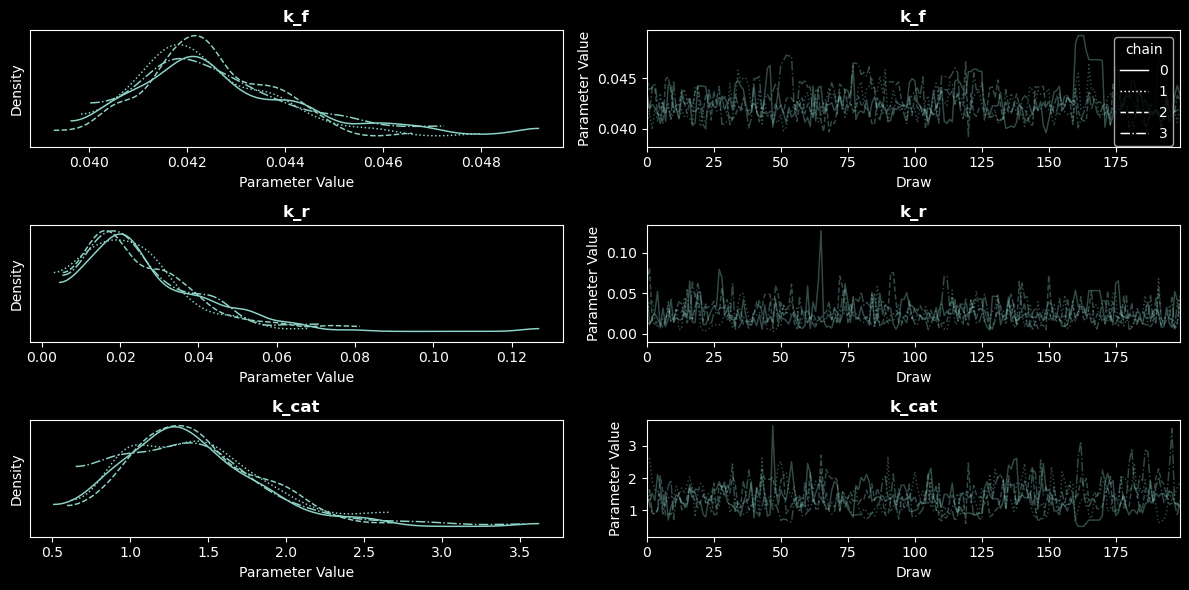

In [24]:
print("\n=== MCMC Summary ===")
summary = az.summary(posterior, var_names=free_params, round_to=4)
display(summary)

# Plot trace 
axes = az.plot_trace(posterior, var_names=free_params, legend=True)

for idx, ax_row in enumerate(axes):
    ax_row[0].set_title(ax_row[0].get_title(), fontweight='bold')
    ax_row[0].set_xlabel("Parameter Value")
    ax_row[0].set_ylabel("Density")
    ax_row[1].set_title(ax_row[1].get_title(), fontweight='bold')
    ax_row[1].set_xlabel("Draw")
    ax_row[1].set_ylabel("Parameter Value")
    
plt.style.use('default')
plt.tight_layout()